In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('datafile.csv')
print(df.shape)

(706, 109)


In [12]:
# Rename long columns for usability
df = df.rename(columns={
    'State/UT': 'state',
    'District Names': 'district',
    'Institutional births (in the 5 years before the survey) (%)': 'institutional_births',
    'Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)': 'anc_4visits',
    "Children age 12-23 months fully vaccinated based on information from either vaccination card or mother\'s recall11 (%)": 'full_vaccination',
    'Children under 5 years who are stunted (height-for-age)18 (%)': 'stunting',
    'Children under 5 years who are underweight (weight-for-age)18 (%)': 'underweight',
    'All women age 15-49 years who are anaemic22 (%)': 'women_anaemia',
    'Children age 6-59 months who are anaemic (<11.0 g/dl)22 (%)': 'child_anaemia',
    'Households using clean fuel for cooking3 (%)': 'clean_fuel',
    'Population living in households that use an improved sanitation facility2 (%)': 'sanitation',
    'Households with any usual member covered under a health insurance/financing scheme (%)': 'health_insurance',
    'Women (age 15-49) who are literate4 (%)': 'women_literacy',
    'Women age 20-24 years married before age 18 years (%)': 'child_marriage',
    'Average out-of-pocket expenditure per delivery in a public health facility (for last birth in the 5 years before the survey) (Rs.)': 'oop_delivery_cost'
})

# ---- FIX: clean all numeric columns ----
cols_to_clean = [
    'institutional_births', 'anc_4visits', 'full_vaccination',
    'stunting', 'underweight', 'women_anaemia', 'child_anaemia',
    'clean_fuel', 'sanitation', 'health_insurance',
    'women_literacy', 'child_marriage', 'oop_delivery_cost'
]

for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# State-level aggregates
state_df = df.groupby('state')[cols_to_clean].mean().reset_index()

print(state_df.shape)
state_df.head()

(36, 14)


,state,institutional_births,anc_4visits,full_vaccination,stunting,underweight,women_anaemia,child_anaemia,clean_fuel,sanitation,health_insurance,women_literacy,child_marriage,oop_delivery_cost
0,Lakshadweep,99.600000,88.300000,NaN,32.000000,25.800000,25.800000,43.100000,59.400000,99.800000,60.100000,96.500000,1.300000,2533.000000
1,Andaman & Nicobar Islands,98.333333,78.933333,NaN,23.233333,28.266667,52.700000,37.166667,70.033333,86.400000,2.000000,86.066667,14.633333,2547.333333
2,Andhra Pradesh,96.853846,68.715385,71.766667,30.384615,28.769231,59.015385,63.476923,82.869231,76.700000,70.830769,67.646154,29.407692,3126.333333
3,Arunachal Pradesh,80.050000,35.775000,65.377778,26.750000,14.115000,38.850000,56.625000,52.280000,84.540000,28.295000,73.100000,18.210000,9549.150000
4,Assam,85.139394,52.321212,66.691667,35.696970,31.609091,65.745455,69.818182,39.927273,70.109091,61.006061,77.403030,30.509091,5405.242424


In [13]:
# Higher is better for these
positive = ['institutional_births', 'anc_4visits', 'full_vaccination',
            'clean_fuel', 'sanitation', 'health_insurance', 'women_literacy']

# Lower is better for these (invert them)
negative = ['stunting', 'underweight', 'women_anaemia',
            'child_anaemia', 'child_marriage']

# Normalise all to 0-100
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))

for col in positive:
    state_df[col + '_score'] = scaler.fit_transform(state_df[[col]])

for col in negative:
    state_df[col + '_score'] = 100 - scaler.fit_transform(state_df[[col]])

# Composite score = average of all normalised scores
score_cols = [c for c in state_df.columns if c.endswith('_score')]
state_df['health_access_score'] = state_df[score_cols].mean(axis=1)

# Rank states
state_df = state_df.sort_values('health_access_score', ascending=False).reset_index(drop=True)
state_df['rank'] = state_df.index + 1

print(state_df[['state', 'health_access_score', 'rank']].to_string())

                                     state  health_access_score  rank
0                                      Goa            84.437326     1
1                                   Kerala            84.328979     2
2                             Lakshadweep             82.035387     3
3                               Puducherry            76.128025     4
4                               Tamil Nadu            74.568145     5
5                               Chandigarh            72.919570     6
6                                  Mizoram            72.749073     7
7                                   Sikkim            72.672491     8
8                Andaman & Nicobar Islands            68.986030     9
9                              Uttarakhand            67.885946    10
10                            NCT of Delhi            66.195140    11
11                                  Punjab            63.800341    12
12                                 Manipur            63.393412    13
13                  

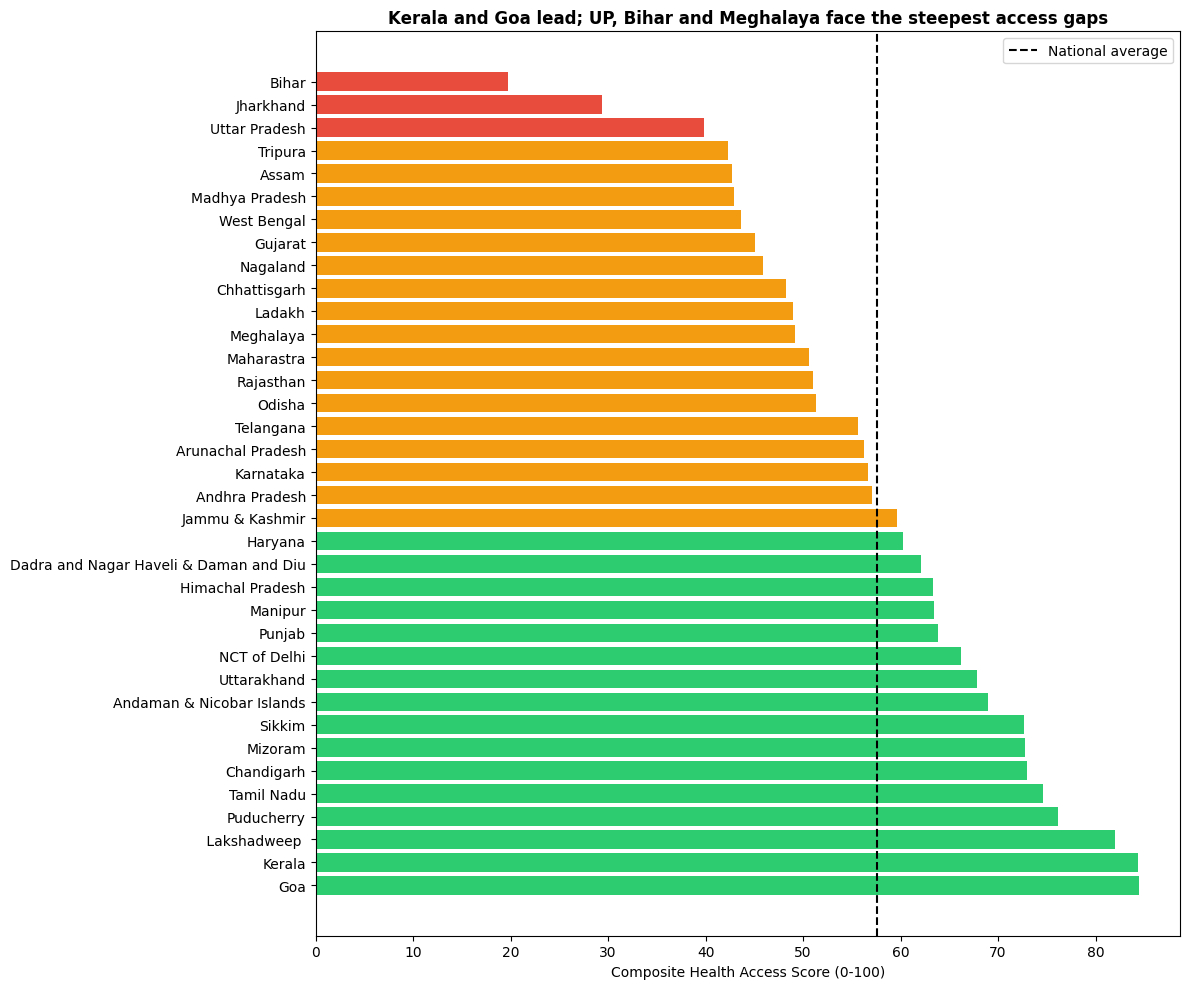

In [14]:
plt.figure(figsize=(12, 10))
colors = ['#2ecc71' if x >= 60 else '#e74c3c' if x < 40 else '#f39c12'
          for x in state_df['health_access_score']]

plt.barh(state_df['state'], state_df['health_access_score'], color=colors)
plt.xlabel('Composite Health Access Score (0-100)')
plt.title('Kerala and Goa lead; UP, Bihar and Meghalaya face the steepest access gaps',
          fontsize=12, fontweight='bold')
plt.axvline(x=state_df['health_access_score'].mean(),
            color='black', linestyle='--', label='National average')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_state_rankings.png', dpi=150)
plt.show()

In [15]:
fig = px.scatter(
    state_df,
    x='health_insurance',
    y='health_access_score',
    text='state',
    title='States with low insurance coverage cluster at the bottom — the protection gap is structural',
    labels={'health_insurance': 'Health Insurance Coverage (%)',
            'health_access_score': 'Health Access Score'},
    color='health_access_score',
    color_continuous_scale='RdYlGn'
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.write_html('chart2_insurance_gap.html')
fig.show()

In [16]:
fig = px.scatter(
    state_df,
    x='child_marriage',
    y='institutional_births',
    text='state',
    size='women_anaemia',
    title='Where child marriage is high, institutional births drop — and anaemia burden grows (bubble size)',
    labels={
        'child_marriage': 'Child Marriage Rate (%)',
        'institutional_births': 'Institutional Births (%)',
        'women_anaemia': 'Women Anaemia (%)'
    },
    color='child_marriage',
    color_continuous_scale='Reds'
)
fig.write_html('chart3_child_marriage.html')
fig.show()

In [17]:
state_df.to_csv('state_health_clean.csv', index=False)
df.to_csv('district_health_clean.csv', index=False)
print("Saved. Upload state_health_clean.csv to Tableau Public.")

Saved. Upload state_health_clean.csv to Tableau Public.


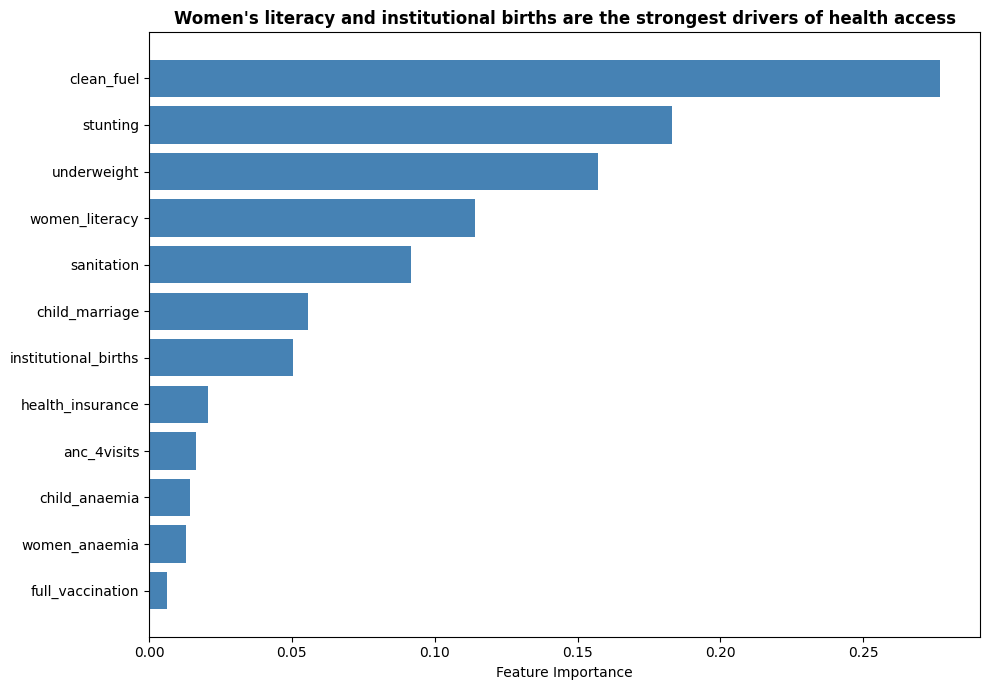

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Features and target
features = ['institutional_births', 'anc_4visits', 'full_vaccination',
            'clean_fuel', 'sanitation', 'health_insurance',
            'women_literacy', 'child_marriage', 'stunting',
            'underweight', 'women_anaemia', 'child_anaemia']

target = 'health_access_score'

# Drop rows with missing values
model_df = state_df[features + [target, 'state']].dropna()

X = model_df[features]
y = model_df[target]

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.title('Women\'s literacy and institutional births are the strongest drivers of health access',
          fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150)
plt.show()

In [19]:
# Predict scores for all states
model_df['predicted_score'] = rf.predict(X)
model_df['gap'] = model_df['health_access_score'] - model_df['predicted_score']

# Underperformers = actual score much lower than predicted
# These states have the inputs to do better but aren't
underperformers = model_df.sort_values('gap').head(8)
overperformers = model_df.sort_values('gap', ascending=False).head(5)

print("=== UNDERPERFORMERS (actual much worse than predicted) ===")
print(underperformers[['state', 'health_access_score', 'predicted_score', 'gap']].to_string())

print("\n=== OVERPERFORMERS (doing better than expected) ===")
print(overperformers[['state', 'health_access_score', 'predicted_score', 'gap']].to_string())

=== UNDERPERFORMERS (actual much worse than predicted) ===
                state  health_access_score  predicted_score       gap
35              Bihar            19.685661        25.549632 -5.863971
34          Jharkhand            29.370158        33.100134 -3.729976
28            Gujarat            45.048959        48.577392 -3.528433
33      Uttar Pradesh            39.843999        43.182936 -3.338937
19  Arunachal Pradesh            56.199712        58.436573 -2.236861
27           Nagaland            45.857290        47.700630 -1.843340
23         Maharastra            50.563677        52.301212 -1.737535
32            Tripura            42.342723        43.873620 -1.530897

=== OVERPERFORMERS (doing better than expected) ===
                                     state  health_access_score  predicted_score       gap
1                                   Kerala            84.328979        78.066217  6.262762
4                               Tamil Nadu            74.568145        68.37

In [20]:
import plotly.express as px

fig = px.scatter(
    model_df,
    x='predicted_score',
    y='health_access_score',
    text='state',
    title='States below the line are underperforming their potential — these are the priority intervention targets',
    labels={
        'predicted_score': 'Predicted Score (based on resources & inputs)',
        'health_access_score': 'Actual Health Access Score'
    },
    color='gap',
    color_continuous_scale='RdYlGn'
)

# Add diagonal reference line
fig.add_shape(
    type='line', x0=0, y0=0, x1=100, y1=100,
    line=dict(color='black', dash='dash')
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.write_html('chart5_underperformers.html')
fig.show()